# Step 1: Dataset Loading and Understanding

In this step, we load the Android app permission dataset and inspect its structure
to understand available features for privacy–convenience analysis.

In [1]:
import pandas as pd

df = pd.read_csv("../data/Extracted_permssion_updated.csv")
df.shape

(200, 324)

# Step 2: Column Inspection

- Inspect all columns present in the dataset  
- Identify Android app permission–related features  

- Separate permission columns from non-permission metadata  
- Reduce high dimensionality for focused privacy analysis  
- Prepare features for risk scoring and clustering

In [2]:
df.columns

Index(['pkgname', 'App categore  ', 'Downloads', 'ACCESS_CHECKIN_PROPERTIES',
       'ACCESS_COARSE_LOCATION', 'ACCESS_FINE_LOCATION',
       'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_NETWORK_STATE',
       'ACCESS_NOTIFICATION_POLICY', 'ACCESS_WIFI_STATE',
       ...
       'android.os.action.POWER_SAVE_MODE_CHANGED', 'CALENDAR', 'CAMERA.1',
       'CONTACTS', 'LOCATION', 'MICROPHONE', 'PHONE', 'SENSORS', 'SMS',
       'STORAGE'],
      dtype='str', length=324)

In [3]:
len(df.columns)

324

### Layer 1: Keyword-based Permission Identification

- Permissions are identified using common Android privacy-sensitive keywords
- Focuses on permissions related to user data access and device sensors
- Filters out non-relevant metadata and system attributes

In [4]:
# Layer 1: Keyword-based permission extraction

permission_keywords = [
    'READ', 'WRITE', 'ACCESS', 'CAMERA', 'LOCATION',
    'CONTACT', 'SMS', 'AUDIO', 'PHONE', 'STORAGE'
]

permission_cols = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in permission_keywords)
]

len(permission_cols)

68

In [5]:
#Viewing Permission columns 
permission_cols[:20]

['ACCESS_CHECKIN_PROPERTIES',
 'ACCESS_COARSE_LOCATION',
 'ACCESS_FINE_LOCATION',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'ACCESS_NETWORK_STATE',
 'ACCESS_NOTIFICATION_POLICY',
 'ACCESS_WIFI_STATE',
 'BIND_ACCESSIBILITY_SERVICE',
 'BROADCAST_SMS',
 'CALL_PHONE',
 'CAMERA',
 'CAPTURE_AUDIO_OUTPUT',
 'CONTROL_LOCATION_UPDATES',
 'INSTALL_LOCATION_PROVIDER',
 'LOCATION_HARDWARE',
 'MODIFY_AUDIO_SETTINGS',
 'MODIFY_PHONE_STATE',
 'READ_CALENDAR',
 'READ_CALL_LOG',
 'READ_CONTACTS']

### Layer 2: Binary Validation of Permission Features

- Binary-valued columns (0/1) are identified across the dataset
- Ensures no major permission-related features are missed
- Helps validate completeness of keyword-based selection

In [6]:
# Layer 2: Identify binary columns (potential permission flags)

binary_cols = [
    col for col in df.columns
    if set(df[col].dropna().unique()).issubset({0, 1})
]

len(binary_cols)

320

- Binary validation was used for dataset verification only  
- Privacy analysis was restricted to keyword-selected permissions  
- Non-privacy system flags were intentionally excluded

In [7]:
df_final = df[permission_cols]
df_final.shape

(200, 68)

## Step 3: Permission Risk Categorization
- From the pool of 68 privacy-relevant permissions, a representative subset is selected
- The selected permissions are categorized based on their privacy impact
- High-risk permissions access sensitive personal data
- Medium-risk permissions indirectly affect privacy
- Low-risk permissions have minimal privacy impact

In [8]:
# Selected high-risk permissions (subset from privacy-relevant pool)
selected_high_risk_permissions = [
    'ACCESS_FINE_LOCATION', 'ACCESS_COARSE_LOCATION',
    'READ_CONTACTS', 'READ_SMS', 'READ_CALL_LOG',
    'CAMERA', 'CAPTURE_AUDIO_OUTPUT',
    'RECORD_AUDIO', 'READ_EXTERNAL_STORAGE',
    'WRITE_EXTERNAL_STORAGE'
]

# Selected medium-risk permissions
selected_medium_risk_permissions = [
    'ACCESS_NETWORK_STATE', 'ACCESS_WIFI_STATE',
    'READ_CALENDAR', 'WRITE_CALENDAR',
    'CALL_PHONE', 'MODIFY_PHONE_STATE'
]

# Selected low-risk permissions
selected_low_risk_permissions = [
    'VIBRATE', 'WAKE_LOCK',
    'ACCESS_NOTIFICATION_POLICY'
]

In [9]:
high_risk = [p for p in selected_high_risk_permissions if p in permission_cols]
medium_risk = [p for p in selected_medium_risk_permissions if p in permission_cols]
low_risk = [p for p in selected_low_risk_permissions if p in permission_cols]

## Step 4: Privacy Risk Score Construction

- Categorized permissions into high, medium, and low privacy risk groups
- Assigned risk weights based on sensitivity and user data exposure
- Aggregated selected permission flags into a single privacy risk score
- Normalized the risk score to enable fair comparison across apps
- Created a quantitative measure of privacy exposure for further analysis

In [10]:
# DefiningRisk weights
HIGH_WEIGHT = 3
MEDIUM_WEIGHT = 2
LOW_WEIGHT = 1

In [11]:
#Ensuring Selected Permissions exist 
selected_permissions = high_risk + medium_risk + low_risk
len(selected_permissions)

17

In [12]:
#Compute Privacy Risk Score
# Create a copy for scoring
df_risk = df[selected_permissions].copy()

# Apply weights
for col in high_risk:
    df_risk[col] = df_risk[col] * HIGH_WEIGHT

for col in medium_risk:
    df_risk[col] = df_risk[col] * MEDIUM_WEIGHT

for col in low_risk:
    df_risk[col] = df_risk[col] * LOW_WEIGHT

# Aggregate into a single score
df['privacy_risk_score'] = df_risk.sum(axis=1)

df[['privacy_risk_score']].head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_15604\1587596469.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['privacy_risk_score'] = df_risk.sum(axis=1)


,privacy_risk_score
0,10
1,22
2,24
3,6
4,16


In [13]:
#Optimizing 
# Use only selected privacy-relevant permission columns
df_risk = df_final.copy()

# Compute privacy risk score
df['privacy_risk_score'] = df_risk.sum(axis=1)

In [14]:
#Quick sanity Check 
df['privacy_risk_score'].describe()

count    200.000000
mean       8.255000
std        5.111813
min        1.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       35.000000
Name: privacy_risk_score, dtype: float64

In [15]:
# Risk Score Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['risk_normalized'] = scaler.fit_transform(
    df[['privacy_risk_score']]
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_15604\1033302230.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['risk_normalized'] = scaler.fit_transform(


In [16]:
# Optimization: reduce DataFrame fragmentation
df = df.copy()

## Step 5: Risk-Based Clustering of Applications

- Use normalized privacy risk scores for clustering
- Apply unsupervised learning to group apps by privacy exposure
- Identify Low, Medium, and High privacy risk app segments
- Enable interpretable risk profiling without predefined labels

In [17]:
# Feature used for clustering
X_cluster = df[['risk_normalized']].copy()

X_cluster.head()

,risk_normalized
0,0.294118
1,0.235294
2,0.294118
3,0.029412
4,0.411765


In [18]:
from sklearn.cluster import KMeans
# Applying k-means clustering 

kmeans = KMeans(n_clusters=3, random_state=42)
df['risk_cluster'] = kmeans.fit_predict(X_cluster)

df[['privacy_risk_score', 'risk_normalized', 'risk_cluster']].head()

,privacy_risk_score,risk_normalized,risk_cluster
0,11,0.294118,1
1,9,0.235294,1
2,11,0.294118,1
3,2,0.029412,0
4,15,0.411765,1


In [19]:
# Analyze clusters
cluster_summary = df.groupby('risk_cluster')['privacy_risk_score'].describe()
cluster_summary

,count,mean,std,min,25%,50%,75%,max
risk_cluster,,,,,,,,
0,106.0,4.839623,1.932858,1.0,4.0,5.0,7.0,7.0
1,82.0,10.597561,2.345786,8.0,9.0,10.0,12.0,16.0
2,12.0,22.416667,4.944388,18.0,19.0,21.0,23.0,35.0


In [20]:
# Compute mean risk score per cluster
cluster_means = df.groupby('risk_cluster')['privacy_risk_score'].mean()

# Map clusters to semantic labels
risk_mapping = {
    cluster_means.idxmin(): 'Low Risk',
    cluster_means.idxmax(): 'High Risk'
}

# Remaining cluster becomes Medium Risk
for c in cluster_means.index:
    if c not in risk_mapping:
        risk_mapping[c] = 'Medium Risk'

df['risk_profile'] = df['risk_cluster'].map(risk_mapping)

df[['privacy_risk_score', 'risk_profile']].head()

,privacy_risk_score,risk_profile
0,11,Medium Risk
1,9,Medium Risk
2,11,Medium Risk
3,2,Low Risk
4,15,Medium Risk


In [21]:
risk_mapping = {
    cluster_means.idxmin(): 'Low Risk',
    cluster_means.idxmax(): 'High Risk'
}

In [22]:
df[['privacy_risk_score', 'risk_profile']]

,privacy_risk_score,risk_profile
0,11,Medium Risk
1,9,Medium Risk
2,11,Medium Risk
3,2,Low Risk
4,15,Medium Risk
...,...,...
195,11,Medium Risk
196,9,Medium Risk
197,8,Medium Risk
198,7,Low Risk


In [23]:
# to show the counts of all risk profiles
df['risk_profile'].value_counts()

risk_profile
Low Risk       106
Medium Risk     82
High Risk       12
Name: count, dtype: int64

## Step 6: Risk Profile Interpretation and Insights

This step interprets the clustering results to extract
meaningful privacy insights for users and analysts.

- Low-risk apps request minimal permissions
- Medium-risk apps balance functionality and exposure
- High-risk apps request multiple sensitive permissions

A small subset of applications contributes disproportionately
to overall privacy exposure, highlighting the importance of
targeted risk awareness instead of blanket restrictions.

In [24]:
# Distribution of Risk Profiles
df['risk_profile'].value_counts()

risk_profile
Low Risk       106
Medium Risk     82
High Risk       12
Name: count, dtype: int64

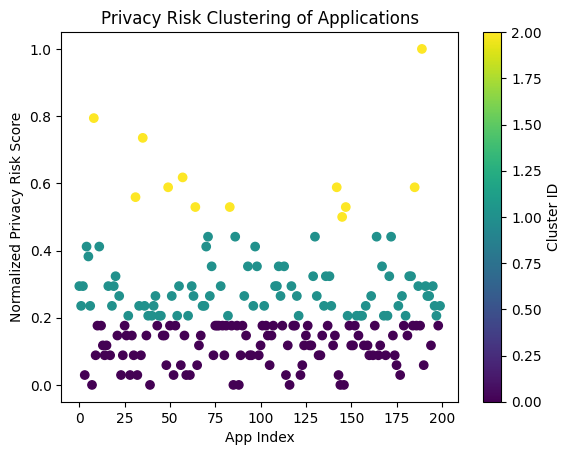

In [27]:
import matplotlib.pyplot as plt

plt.figure()

scatter = plt.scatter(
    df.index,
    df['risk_normalized'],
    c=df['risk_cluster'],
    cmap='viridis'
)

plt.colorbar(scatter, label="Cluster ID")

plt.xlabel("App Index")
plt.ylabel("Normalized Privacy Risk Score")
plt.title("Privacy Risk Clustering of Applications")

plt.show()

In [28]:
df.groupby('risk_profile')['privacy_risk_score'].describe()

,count,mean,std,min,25%,50%,75%,max
risk_profile,,,,,,,,
High Risk,12.0,22.416667,4.944388,18.0,19.0,21.0,23.0,35.0
Low Risk,106.0,4.839623,1.932858,1.0,4.0,5.0,7.0,7.0
Medium Risk,82.0,10.597561,2.345786,8.0,9.0,10.0,12.0,16.0


In [31]:
df.columns.tolist()

['pkgname',
 'App categore  ',
 'Downloads',
 'ACCESS_CHECKIN_PROPERTIES',
 'ACCESS_COARSE_LOCATION',
 'ACCESS_FINE_LOCATION',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'ACCESS_NETWORK_STATE',
 'ACCESS_NOTIFICATION_POLICY',
 'ACCESS_WIFI_STATE',
 'ACCOUNT_MANAGER',
 'ADD_VOICEMAIL',
 'BATTERY_STATS',
 'BIND_ACCESSIBILITY_SERVICE',
 'BIND_APPWIDGET',
 'BIND_CARRIER_MESSAGING_SERVICE',
 'BIND_CARRIER_SERVICES',
 'BIND_CHOOSER_TARGET_SERVICE',
 'BIND_CONDITION_PROVIDER_SERVICE',
 'BIND_DEVICE_ADMIN',
 'BIND_DREAM_SERVICE',
 'BIND_INCALL_SERVICE',
 'BIND_INPUT_METHOD',
 'BIND_MIDI_DEVICE_SERVICE',
 'BIND_NFC_SERVICE',
 'BIND_NOTIFICATION_LISTENER_SERVICE',
 'BIND_PRINT_SERVICE',
 'BIND_QUICK_SETTINGS_TILE',
 'BIND_REMOTEVIEWS',
 'BIND_SCREENING_SERVICE',
 'BIND_TELECOM_CONNECTION_SERVICE',
 'BIND_TEXT_SERVICE',
 'BIND_TV_INPUT',
 'BIND_VOICE_INTERACTION',
 'BIND_VPN_SERVICE',
 'BIND_VR_LISTENER_SERVICE',
 'BIND_WALLPAPER',
 'BLUETOOTH',
 'BLUETOOTH_ADMIN',
 'BLUETOOTH_PRIVILEGED',
 'BODY_SENSORS

In [32]:
df.columns = df.columns.str.strip()

In [33]:
df.columns.tolist()

['pkgname',
 'App categore',
 'Downloads',
 'ACCESS_CHECKIN_PROPERTIES',
 'ACCESS_COARSE_LOCATION',
 'ACCESS_FINE_LOCATION',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'ACCESS_NETWORK_STATE',
 'ACCESS_NOTIFICATION_POLICY',
 'ACCESS_WIFI_STATE',
 'ACCOUNT_MANAGER',
 'ADD_VOICEMAIL',
 'BATTERY_STATS',
 'BIND_ACCESSIBILITY_SERVICE',
 'BIND_APPWIDGET',
 'BIND_CARRIER_MESSAGING_SERVICE',
 'BIND_CARRIER_SERVICES',
 'BIND_CHOOSER_TARGET_SERVICE',
 'BIND_CONDITION_PROVIDER_SERVICE',
 'BIND_DEVICE_ADMIN',
 'BIND_DREAM_SERVICE',
 'BIND_INCALL_SERVICE',
 'BIND_INPUT_METHOD',
 'BIND_MIDI_DEVICE_SERVICE',
 'BIND_NFC_SERVICE',
 'BIND_NOTIFICATION_LISTENER_SERVICE',
 'BIND_PRINT_SERVICE',
 'BIND_QUICK_SETTINGS_TILE',
 'BIND_REMOTEVIEWS',
 'BIND_SCREENING_SERVICE',
 'BIND_TELECOM_CONNECTION_SERVICE',
 'BIND_TEXT_SERVICE',
 'BIND_TV_INPUT',
 'BIND_VOICE_INTERACTION',
 'BIND_VPN_SERVICE',
 'BIND_VR_LISTENER_SERVICE',
 'BIND_WALLPAPER',
 'BLUETOOTH',
 'BLUETOOTH_ADMIN',
 'BLUETOOTH_PRIVILEGED',
 'BODY_SENSORS',

In [ ]:
# Displaying high risk apps 
df[df['risk_profile'] == 'High Risk'] \
  .sort_values('privacy_risk_score', ascending=False) \
  .head(5)[['pkgname', 'App categore', 'privacy_risk_score']]

,pkgname,App categore,privacy_risk_score
189,whatsApp,Communications,35
8,Andriod Auto,Auto & Vehicles,28
35,deezer,Music & Audio,26
57,Gmail,Communications,22
185,Waze,Maps & Navigation,21
